# Antibiotic Resistance Gene Analysis in *Acinetobacter baumannii*
## Comparison of 5 Antibiotic Resistance Gene Databases (ABRicate)

**Author:** Haydé Saracho  
**Date:** 2026  
**Tools:** ABRicate, Python, Pandas, Matplotlib, Seaborn  
**Databases:** CARD, ResFinder, ARG-ANNOT, MEGARES, NCBI AMRFinderPlus

## 1. Imports and data loading

In [17]:
# --- Libraries ---------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# --- Style configuration -------------------------------------------------
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


In [18]:
# --- Paths -------------------------------------------------------------------
RESULTS_DIR = Path("../../results")

DB_FILES = {
    "CARD":              RESULTS_DIR / "CARD/card_results.tsv",
    "ResFinder":         RESULTS_DIR / "ResFinder/resfinder_results.tsv",
    "ARG-ANNOT":         RESULTS_DIR / "ARG-ANNOT/argannot_results.tsv",
    "MEGARES":           RESULTS_DIR / "MEGARES/megares_results.tsv",
    "NCBIAMRFinderPlus": RESULTS_DIR / "NCBIAMRFinderPlus/ncbi_results.tsv",
}

# --- Load and combine -------------------------------------------------------
dfs = []
for db_name, filepath in DB_FILES.items():
    df = pd.read_csv(filepath, sep="\t")
    df["DATABASE"] = db_name
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

print(f"Total combined hits: {len(combined):,}")
print(f"Columns: {list(combined.columns)}")
combined.head()

Total combined hits: 102,171
Columns: ['#FILE', 'SEQUENCE', 'START', 'END', 'STRAND', 'GENE', 'COVERAGE', 'COVERAGE_MAP', 'GAPS', '%COVERAGE', '%IDENTITY', 'DATABASE', 'ACCESSION', 'PRODUCT', 'RESISTANCE']


,#FILE,SEQUENCE,START,END,STRAND,GENE,COVERAGE,COVERAGE_MAP,GAPS,%COVERAGE,%IDENTITY,DATABASE,ACCESSION,PRODUCT,RESISTANCE
0,../data/raw/genomes/GCF_000018445.1_ASM1844v1_...,NC_010605.1,13384,14226,+,OXA-58,1-843/843,===============,0/0,100.0,100.00,CARD,CP000864.1:13383-14226,OXA-58 is a beta-lactamase found in A. baumannii.,carbapenem;penicillin_beta-lactam
1,../data/raw/genomes/GCF_000018445.1_ASM1844v1_...,NC_010605.1,17398,18240,+,OXA-58,1-843/843,===============,0/0,100.0,100.00,CARD,CP000864.1:13383-14226,OXA-58 is a beta-lactamase found in A. baumannii.,carbapenem;penicillin_beta-lactam
2,../data/raw/genomes/GCF_000018445.1_ASM1844v1_...,NC_010611.1,180225,181013,+,ANT(3'')-IIa,1-789/789,===============,0/0,100.0,98.73,CARD,GG704579.1:35369-34580,ANT(3'')-IIa is a aminoglycoside nucleotidyltr...,aminoglycoside
3,../data/raw/genomes/GCF_000018445.1_ASM1844v1_...,NC_010611.1,250610,251414,+,AAC(6')-Ib7,1-786/786,========/======,1/19,100.0,97.64,CARD,KR091911.1:75350-74564,AAC(6')-Ib7 is a plasmid-encoded aminoglycosid...,aminoglycoside
4,../data/raw/genomes/GCF_000018445.1_ASM1844v1_...,NC_010611.1,251962,252762,+,OXA-20,1-801/801,===============,0/0,100.0,100.00,CARD,CP000863.1:251961-252762,OXA-20 is a beta-lactamase found in P. aerugin...,penicillin_beta-lactam


## 2. Genome identifier processing

In [19]:
# Extract only the accession (GCF_XXXXXXX) from the full path
combined["GENOME"] = combined["#FILE"].apply(
    lambda x: Path(x).name.replace("_genomic.fna.gz", "")
)

# Verify
print(f"Unique genomes: {combined['GENOME'].nunique()}")
print(f"Databases: {combined['DATABASE'].unique()}")
combined[["GENOME", "GENE", "DATABASE"]].head()

Unique genomes: 1012
Databases: ['CARD' 'ResFinder' 'ARG-ANNOT' 'MEGARES' 'NCBIAMRFinderPlus']


,GENOME,GENE,DATABASE
0,GCF_000018445.1_ASM1844v1,OXA-58,CARD
1,GCF_000018445.1_ASM1844v1,OXA-58,CARD
2,GCF_000018445.1_ASM1844v1,ANT(3'')-IIa,CARD
3,GCF_000018445.1_ASM1844v1,AAC(6')-Ib7,CARD
4,GCF_000018445.1_ASM1844v1,OXA-20,CARD


In [20]:
# The same gene may have different names across databases.
# Show examples of gene names per database
for db in combined["DATABASE"].unique():
    print(f"\n--- {db} ---")
    print(combined[combined["DATABASE"] == db]["GENE"].value_counts().head(10).to_string())


--- CARD ---
GENE
adeJ                            1014
adeI                            1014
adeH                            1014
adeK                            1013
LpsB                            1013
Acinetobacter_baumannii_AmvA    1013
abeS                            1013
adeG                            1011
adeL                            1011
abeM                            1007

--- ResFinder ---
GENE
blaADC-25_1      1058
blaOXA-23_1       979
aph(6)-Id_1       633
sul1_5            575
aph(3'')-Ib_2     575
sul2_2            524
aph(3')-Ia_7      508
msr(E)_1          505
mph(E)_1          498
tet(B)_1          484

--- ARG-ANNOT ---
GENE
(Bla)Mbl                       1012
(Bla)Zn-dependent_hydrolase    1008
(Bla)blaOXA-23                  984
(AGly)ant(3'')-IIa              971
(Bla)BlaA1                      952
(Bla)BlaA2                      940
(AGly)strB                      633
(AGly)strA                      631
(Sul)sul1                       578
(Sul)sul2          

## 3. Gene name normalization

In [21]:
# Diccionario de correcciones manuales
corrections = {
    "suli":                    "sul1",
    # ARG-ANNOT
    "adc":                     "blaadc",
    "aada1-pm":  "aada",
    "aada2":     "aada",
    "aada5":     "aada",
    "aada6":     "aada",
    "aada16":    "aada",
    "aada17":    "aada",
    "carb":                    "blacarb",
    "ctx-m":                   "blactx",
    "ges":                     "blages",
    "imp":                     "blaimp",
    "ndm":                     "blandm",
    "oxa":                     "blaoxa",
    "per":                     "blaper",
    "shv":                     "blashv",
    "tem":                     "blatem",
    "veb":                     "blaveb",
    "tet(39)":                 "tet39",
    "tetr(g)":                 "tetrg",
    "zn-dependent_hydrolase":  "blazn",
    "beta-lactamase_class-c":  "blac",
    "teta":                    "tet(a)",
    "tetb":                    "tet(b)",
    "tetc":                    "tet(c)",
    "tetg":                    "tet(g)",
    "tetm":                    "tet(m)",
    "tetx":                    "tet(x)",
    "tety":                    "tet(y)",
    "arr2":                    "arr",
    "arr3":                    "arr",
    "aph3-ia":                 "aph3",
    "aph3-vib":                "aph3",
    "aph4-ia":                 "aph4",
    "apha6":                   "aph6",
    "aac3-i":                  "aac3",
    "aac3-iia":                "aac3",
    "aac3-iid":                "aac3",
    "aac6-iaf":                "aac6",
    "aac6-ib":                 "aac6",
    "aac6-iia":                "aac6",
    "aac-iva":   "aac4a",
    "fosa3":     "fosa",
    "qnrvc6":    "qnrvc",
    "sat":   "sat2",
    # CARD
    "aac(6')-ib7":             "aac6",
    "aada2":     "aada",
    "aada5":     "aada",
    "aada16":    "aada",
    "aada17":    "aada",
    "cmla1":     "cmla",
    "cmla5":     "cmla",
    "cmla6":     "cmla",
    "cmla9":     "cmla",
    "catb2":     "catb",
    "catb3":     "catb",
    "catb8":     "catb",
    "catb11":    "catb",
    "cmlb1":     "cmlb",
    "aac(6')-ib8":             "aac6",
    "aac(6')-ib9":             "aac6",
    "aac(6')-ib10":            "aac6",
    "aac(6')-ib-akt":          "aac6",
    "aac(6')-ib":              "aac6",
    "aac(6')-ian":             "aac6",
    "aac(6')-iaf":             "aac6",
    "aac(6')-iia":             "aac6",
    "aac6-prime":              "aac6",
    "aac(3)-ia":               "aac3",
    "aac(3)-iid":              "aac3",
    "aac(3)-iie":              "aac3",
    "aac(3)-iva":              "aac3",
    "aph(3')-ia":              "aph3",
    "aph(3')-via":             "aph3",
    "aph(3')-vib":             "aph3",
    "aph(3'')":                "aph3",
    "aph(3'')-ib":             "aph3",
    "aph(3'')-ia":             "aph3",
    "aph(4)-ia":               "aph4",
    "aph(6)-id":               "aph6",
    "ant(2'')":                "ant2",
    "ant(2'')-ia":             "ant2",
    "ant(3'')-iia":            "ant3",
    "ampc_beta-lactamase":     "ampc",
    "brp(mbl)":                "brpmbl",
    "mcr-4.3":                 "mcr",
    "cmy":                     "blacmy",
    "gim":                     "blagim",
    "sco":                     "blasco",
    "tmb":                     "blatmb",
    "ermb":                    "erm(b)",
    "ereb":                    "ere(b)",
    "mphe":                    "mph(e)",
    "msre":                    "msr(e)",
    "tet(x3)":                 "tet(x)",
    "tet(x5)":                 "tet(x)",
    "tet(x6)":                 "tet(x)",
    "aada11":                  "aada",
    "qacedelta1":              "qacedelta",
    "dfra1":                   "dfr",
    "dfra5":                   "dfr",
    "dfra7":                   "dfr",
    "dfra10":                  "dfr",
    "dfra12":                  "dfr",
    "dfra14":                  "dfr",
    "dfra16":                  "dfr",
    "dfra17":                  "dfr",
    "dfra19":                  "dfr",
    "dfra20":                  "dfr",
    "dfra27":                  "dfr",
    "dfra38":                  "dfr",
    "dfra":                    "dfr",
    "dfrb1":                   "dfr",
    "dfrb":                    "dfr",
    "dfr16":                   "dfr",
    "dhfr7":                   "dhfr",
    "aadt":      "aada",
    "fosa3":     "fosa",
    "qnrvc6":    "qnrvc",
    # MEGARES
    "ant2-dprime":             "ant2",
    "ant3-dprime":             "ant3",
    "aph3-dprime":             "aph3",
    "aph3-prime":              "aph3",
    "sulii":                   "sul2",
    "blaa1":                   "blaa",
    "blaa2":                   "blaa",
    "ctx":                     "blactx",
    "brp":                     "brpmbl",
    "cata1":                   "cata",
    # NCBIAMRFinderPlus
    "aac(6')-ib'":   "aac6",
    "aac(6')-ib-g":  "aac6",
    "aac(6')-ib11":  "aac6",
    "aac(6')-ib4":   "aac6",
    "aac(6')-ip":    "aac6",
    "aaca34":        "aaca",
    "aaca57":        "aaca",
    "aada1":         "aada",
    "ant(3'')-ia":   "ant3",
    "ant(3'')-iid":  "ant3",
    "aph(3')-vi":    "aph3",
    "blamca":        "mca",
    "dfra41":        "dfr",
    "dfra44":        "dfr",
    "dfra45":        "dfr",
    "flor2":         "flor",
    "sat2_fam":      "sat2",
    # ResFinder
    "aac(3)-iia":  "aac3",
    "cmla7":       "cmla",
}

# Familias de betalactamasas donde bla ES un prefijo a eliminar
BLA_FAMILIES = r'^bla(oxa|tem|adc|shv|ctx|ndm|vim|imp|kpc|ges|per|veb|carb|ceph|pse|rob|mbl)'

def normalize_gene(gene):
    g = str(gene)
    # 1. Eliminar prefijos de clase tipo (Bla), (AGly), (Sul), etc.
    g = re.sub(r'^\([^)]+\)', '', g)
    # 2. Minúsculas
    g = g.lower()
    # 3. Eliminar sufijos de alelo tipo _1, _2, _7, etc.
    g = re.sub(r'_\d+$', '', g)
    # 4. Eliminar prefijo de organismo tipo acinetobacter_baumannii_
    g = re.sub(r'^[a-z]+_[a-z]+_', '', g)
    # 5. Eliminar prefijo bla SOLO para familias conocidas
    g = re.sub(BLA_FAMILIES, r'\1', g)
    # 6. Eliminar número de variante alélica tipo -58, -23, -1d
    g = re.sub(r'-\d+[a-z]?$', '', g)
    # 7. Limpiar espacios y guiones bajos sobrantes
    g = g.strip().strip('_')
    # 8. Correcciones manuales
    g = corrections.get(g, g)
    return g

combined["GENE_NORM"] = combined["GENE"].apply(normalize_gene)

# --- Tabla completa: por cada DB, todos los GENE_NORM con sus originales ----
print("=" * 80)
for db in sorted(combined["DATABASE"].unique()):
    print(f"\n{'=' * 80}")
    print(f"BASE DE DATOS: {db}")
    print(f"{'=' * 80}")
    
    db_verif = (
        combined[combined["DATABASE"] == db]
        .groupby("GENE_NORM")["GENE"]
        .apply(lambda x: " | ".join(sorted(x.unique())))
        .reset_index()
    )
    db_verif.columns = ["GENE_NORM", "GENES_ORIGINALES"]
    db_verif = db_verif.sort_values("GENE_NORM")
    
    db_verif["STATUS"] = db_verif["GENES_ORIGINALES"].apply(
        lambda x: "[AGR]" if "|" in x else "[ OK]"
    )
    
    for _, row in db_verif.iterrows():
        print(f"  {row['STATUS']} {row['GENE_NORM']:<30} ← {row['GENES_ORIGINALES'][:80]}")
    
    print(f"\n  Total genes normalizados únicos: {len(db_verif)}")


BASE DE DATOS: ARG-ANNOT
  [AGR] aac3                           ← (AGly)aac3-I | (AGly)aac3-IIa | (AGly)aac3-IId
  [ OK] aac4a                          ← (AGly)aac-IVa
  [AGR] aac6                           ← (AGly)aac(6')-Ian | (AGly)aac6-IIa | (AGly)aac6-Iaf | (AGly)aac6-Ib
  [AGR] aada                           ← (AGly)aadA1-pm | (AGly)aadA16 | (AGly)aadA17 | (AGly)aadA2 | (AGly)aadA5 | (AGly
  [ OK] aadb                           ← (AGly)aadB
  [ OK] ant3                           ← (AGly)ant(3'')-IIa
  [AGR] aph3                           ← (AGly)aph(3'')-Ia | (AGly)aph3-Ia | (AGly)aph3-VIb
  [ OK] aph4                           ← (AGly)aph4-Ia
  [ OK] aph6                           ← (AGly)aphA6
  [ OK] arma                           ← (AGly)armA
  [AGR] arr                            ← (Rif)arr2 | (Rif)arr3
  [AGR] blaa                           ← (Bla)BlaA1 | (Bla)BlaA2
  [AGR] blaadc                         ← (Bla)blaADC-1 | (Bla)blaADC-10 | (Bla)blaADC-2 | (Bla)blaADC-21 | (

## 4. General summary by database

In [22]:
# --- Hits per database --------------------------------------------------
summary = combined.groupby("DATABASE").agg(
    Total_hits   = ("GENE_NORM", "count"),
    Genes_unicos = ("GENE_NORM", "nunique"),
    Genomas      = ("GENOME", "nunique")
).reset_index().sort_values("Total_hits", ascending=False)

print(summary.to_string(index=False))

         DATABASE  Total_hits  Genes_unicos  Genomas
          MEGARES       33594            76     1012
             CARD       30578            75     1012
        ARG-ANNOT       15507            60     1012
NCBIAMRFinderPlus       11938            55     1012
        ResFinder       10554            49     1012


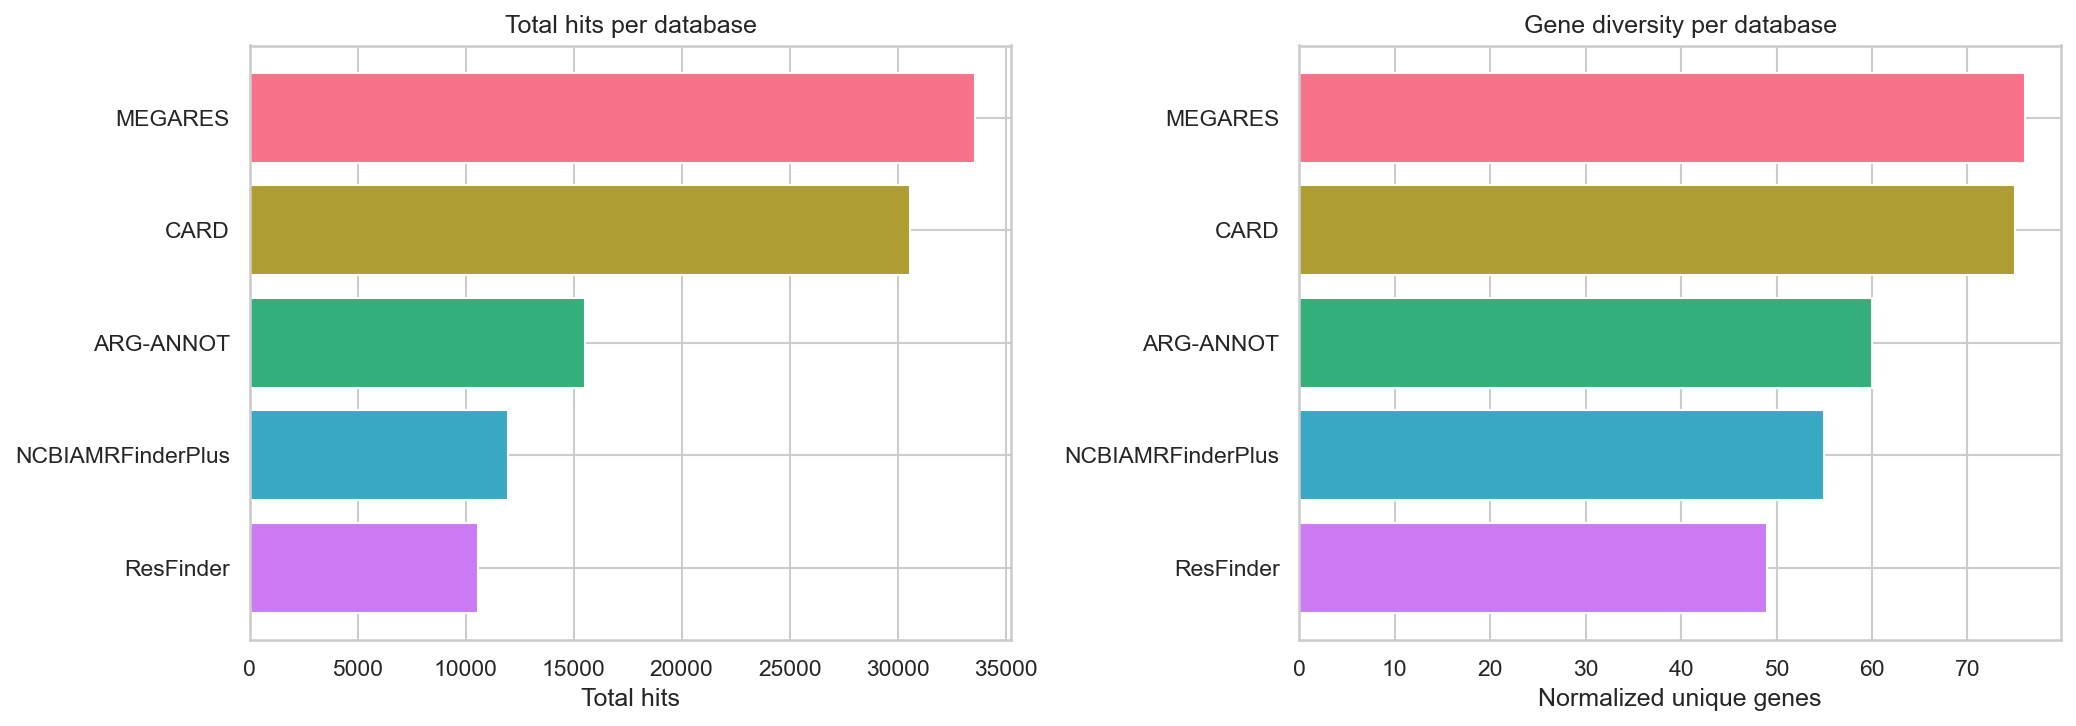

Figure saved to figures/01_summary_per_db.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Total hits --------------------------------------------------------------
axes[0].barh(summary["DATABASE"], summary["Total_hits"],
             color=sns.color_palette("husl", 5))
axes[0].set_xlabel("Total hits")
axes[0].set_title("Total hits per database")
axes[0].invert_yaxis()

# --- Unique genes ------------------------------------------------------------
axes[1].barh(summary["DATABASE"], summary["Genes_unicos"],
             color=sns.color_palette("husl", 5))
axes[1].set_xlabel("Normalized unique genes")
axes[1].set_title("Gene diversity per database")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../../figures/01_resumen_por_db.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to figures/01_summary_per_db.png")

## 5. Most frequent genes per database

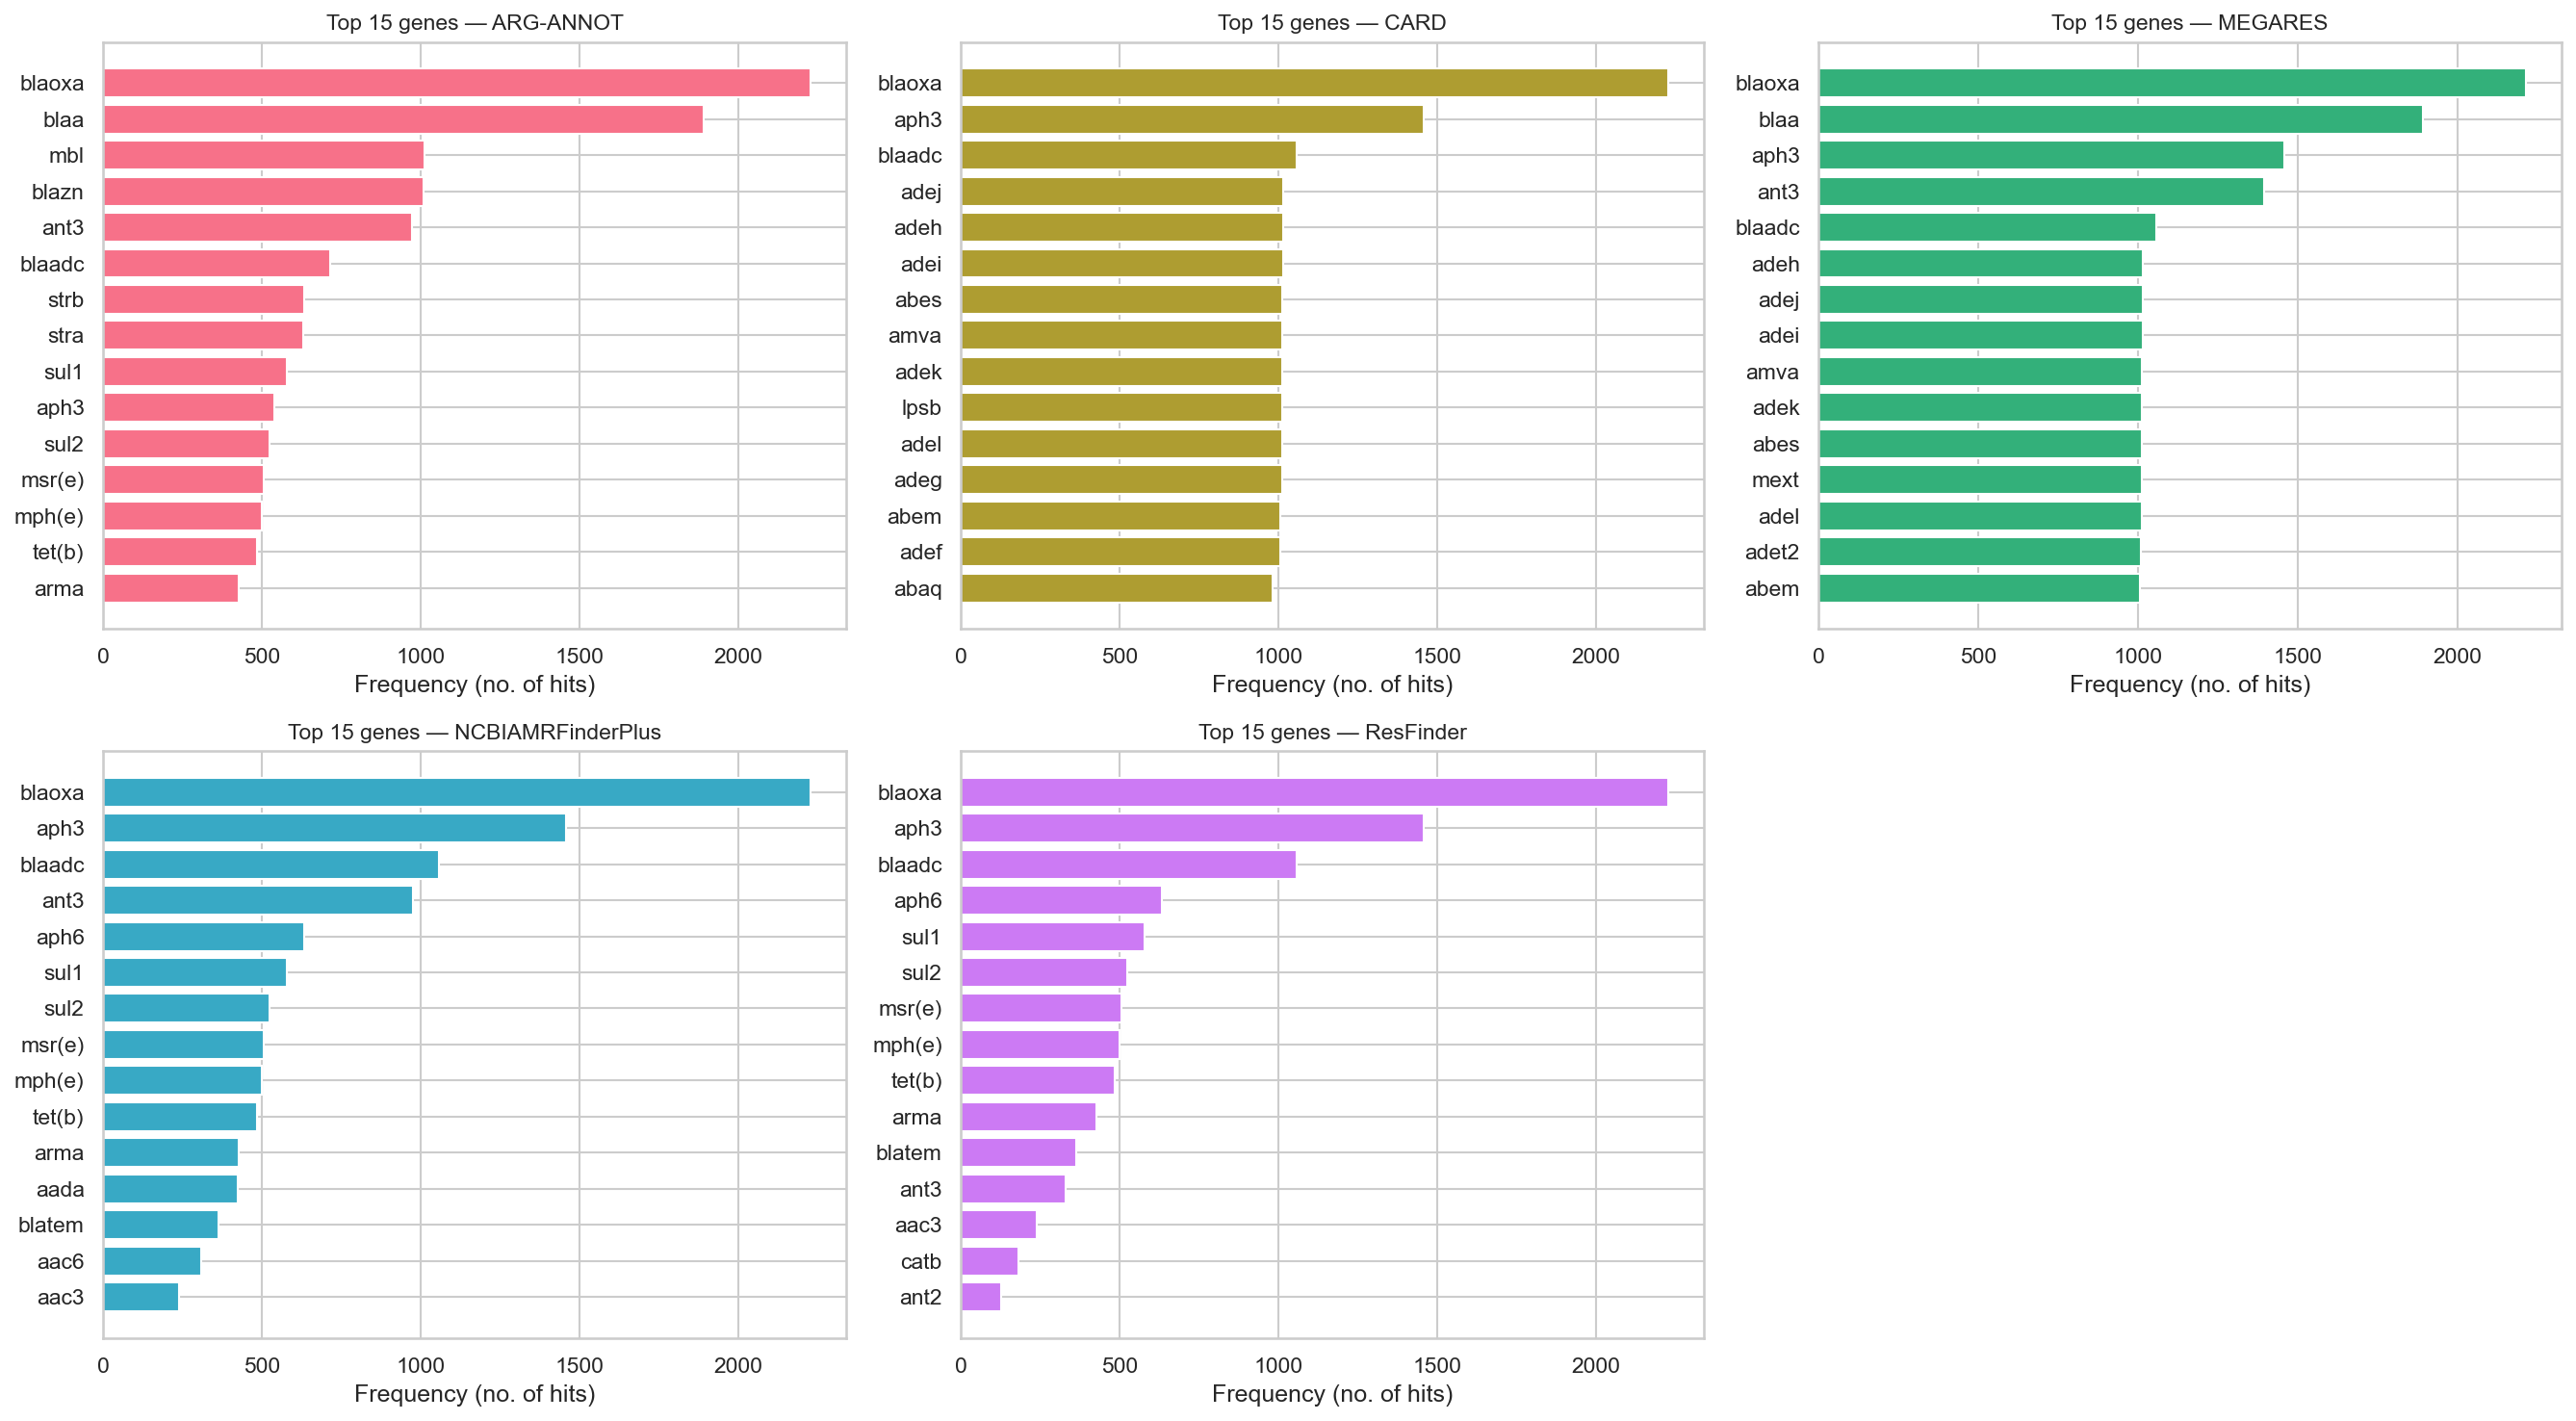

Figure saved to figures/02_top_genes_per_db.png


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (db_name, group) in enumerate(combined.groupby("DATABASE")):
    top_genes = (
        group["GENE_NORM"]
        .value_counts()
        .head(15)
        .reset_index()
    )
    top_genes.columns = ["GENE_NORM", "Count"]

    axes[i].barh(top_genes["GENE_NORM"], top_genes["Count"],
                 color=sns.color_palette("husl", 5)[i])
    axes[i].set_title(f"Top 15 genes — {db_name}", fontsize=11)
    axes[i].set_xlabel("Frequency (no. of hits)")
    axes[i].invert_yaxis()

axes[5].axis("off")

plt.tight_layout()
plt.savefig("../../figures/02_top_genes_por_db.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to figures/02_top_genes_per_db.png")

In [25]:
# blaoxa es el gen más frecuente en las 5 bases de datos.

# CARD y MEGARES muestran muchos genes de bombas de eflujo (adeh, adei, adej, abes, abem) que las otras bases no detectan
# porque esas bases incluyen genes de resistencia intrínseca que NCBI y ResFinder no tienen.

## 6. Genes detected in common across databases

In [26]:
# --- Unique genes por base de datos ------------------------------------------
db_genes = {}
for db in combined["DATABASE"].unique():
    db_genes[db] = set(combined[combined["DATABASE"] == db]["GENE_NORM"].unique())

# --- Genes shared across all databases ------------------------------------
core_genes = db_genes["CARD"]
for db in db_genes:
    core_genes = core_genes & db_genes[db]

print(f"Genes detected by ALL databases ({len(core_genes)}):")
for g in sorted(core_genes):
    print(f"  {g}")

Genes detected by ALL databases (45):
  aac3
  aac6
  ant3
  aph3
  aph4
  aph6
  arma
  arr
  blaadc
  blacarb
  blacmy
  blactx
  blagim
  blaimp
  blandm
  blaoxa
  blaper
  blasco
  blashv
  blatem
  blatmb
  blaveb
  cata
  cmla
  cmlb
  dfr
  ere(b)
  erm(b)
  flor
  fosa
  mcr
  mph(e)
  msr(e)
  qnrvc
  rmtc
  sul1
  sul2
  tet(a)
  tet(b)
  tet(c)
  tet(g)
  tet(m)
  tet(x)
  tet(y)
  tet39


In [27]:
# --- How many databases detect each gene -----------------------------------------
all_genes = set()
for genes in db_genes.values():
    all_genes |= genes

gene_db_count = {}
for gene in all_genes:
    gene_db_count[gene] = sum(1 for genes in db_genes.values() if gene in genes)

count_df = pd.DataFrame({
    "GENE_NORM": list(gene_db_count.keys()),
    "N_DATABASES": list(gene_db_count.values())
}).sort_values("N_DATABASES", ascending=False)

print("Gene distribution by number of databases detecting them:")
print(count_df["N_DATABASES"].value_counts().sort_index(ascending=False).to_string())
print(f"\nTotal genes únicos en el análisis: {len(count_df)}")

Gene distribution by number of databases detecting them:
N_DATABASES
5    45
4     4
3     1
2    23
1    25

Total genes únicos en el análisis: 98


In [28]:
# --- Genes detected by 4 or 3 databases ----------------------------------------
for n in [4, 3]:
    genes = count_df[count_df["N_DATABASES"] == n]["GENE_NORM"].tolist()
    print(f"\nGenes detected by {n} databases ({len(genes)}):")
    for g in sorted(genes):
        # Show which databases detect it
        bases = [db for db, gset in db_genes.items() if g in gset]
        print(f"  {g:<20} ← {', '.join(sorted(bases))}")


Genes detected by 4 databases (4):
  aada                 ← ARG-ANNOT, CARD, NCBIAMRFinderPlus, ResFinder
  ant2                 ← CARD, MEGARES, NCBIAMRFinderPlus, ResFinder
  blages               ← ARG-ANNOT, CARD, NCBIAMRFinderPlus, ResFinder
  catb                 ← ARG-ANNOT, CARD, NCBIAMRFinderPlus, ResFinder

Genes detected by 3 databases (1):
  sat2                 ← ARG-ANNOT, CARD, NCBIAMRFinderPlus


### Gráfico: Distribución de genes por número de bases

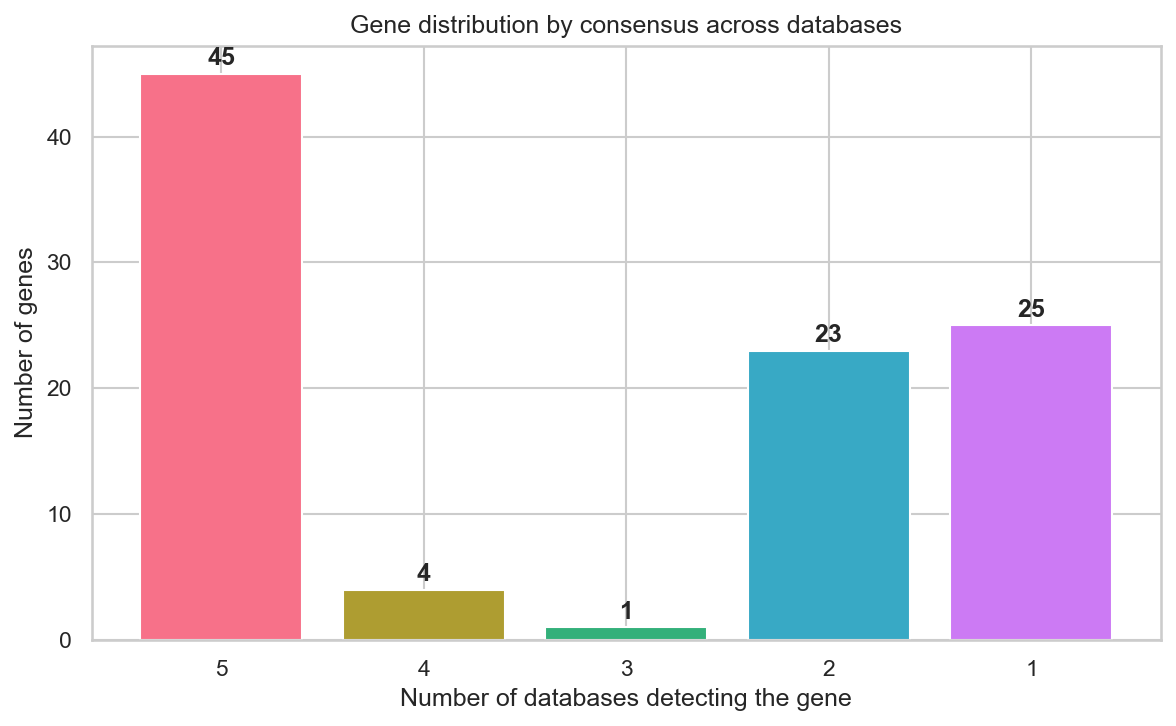

Figure saved to figures/03_gene_consensus.png


In [29]:
dist = count_df["N_DATABASES"].value_counts().sort_index(ascending=False).reset_index()
dist.columns = ["N_bases", "N_genes"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dist["N_bases"].astype(str), dist["N_genes"],
              color=sns.color_palette("husl", 5))

ax.set_xlabel("Number of databases detecting the gene")
ax.set_ylabel("Number of genes")
ax.set_title("Gene distribution by consensus across databases")

for bar, val in zip(bars, dist["N_genes"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("../../figures/03_consenso_genes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to figures/03_gene_consensus.png")

## 7. Presence/absence heatmap of core genes across genomes

In [30]:
# --- Presence/absence matrix for core genes ----------------------------
# Using only the 45 genes detected by all 5 databases

core_list = sorted(core_genes)

# Pivot: rows = genomes, columns = core genes
presence = (
    combined[combined["GENE_NORM"].isin(core_list)]
    .groupby(["GENOME", "GENE_NORM"])
    .size()
    .unstack(fill_value=0)
    .clip(upper=1)  # binary: present/absent
)

print(f"Presence/absence matrix: {presence.shape[0]} genomes × {presence.shape[1]} genes")
presence.head()

Presence/absence matrix: 1012 genomes × 45 genes


GENE_NORM,aac3,aac6,ant3,aph3,aph4,aph6,arma,arr,blaadc,blacarb,...,sul1,sul2,tet(a),tet(b),tet(c),tet(g),tet(m),tet(x),tet(y),tet39
GENOME,,,,,,,,,,,,,,,,,,,,,
GCF_000018445.1_ASM1844v1,0,1,1,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
GCF_000021245.2_ASM2124v2,1,0,1,1,0,0,0,0,1,0,...,1,0,1,0,0,0,0,0,0,0
GCF_000069245.1_ASM6924v1,1,1,1,1,0,1,0,1,1,0,...,1,0,1,0,0,1,0,0,0,0
GCF_000186665.3_ASM18666v4,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
GCF_000187205.2_ASM18720v4,1,1,1,1,0,1,1,0,1,0,...,1,1,0,1,0,0,0,0,0,0


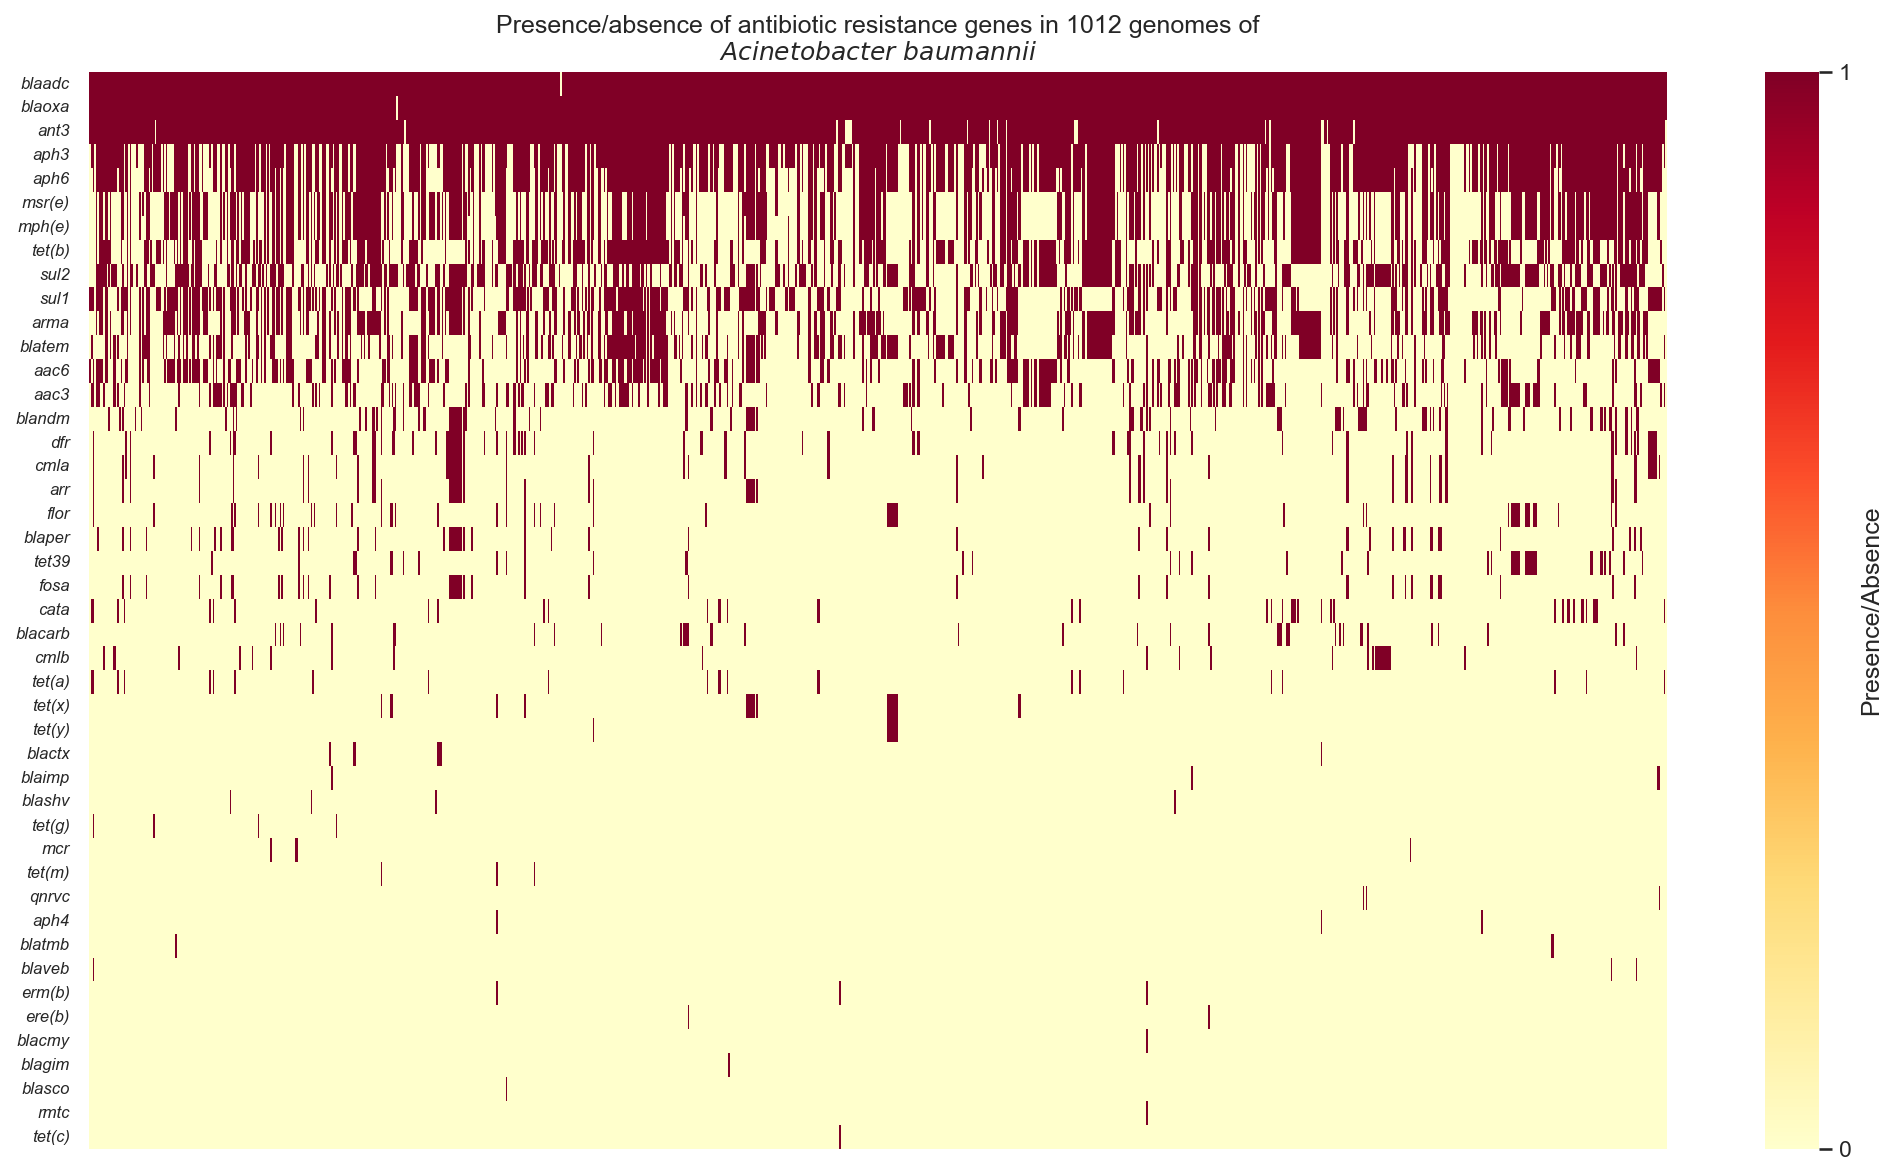

Figure saved to figures/04_heatmap_core_genes.png


In [31]:
# --- Heatmap -----------------------------------------------------------------
gene_freq = presence.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    presence[gene_freq.index].T,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Presence/Absence", "ticks": [0, 1]},
    yticklabels=True,
    xticklabels=False,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Presence/absence of antibiotic resistance genes in 1012 genomes of\n$\\it{Acinetobacter\\ baumannii}$",
             fontsize=12)

# Nombres de genes en cursiva
from matplotlib import font_manager
italic_font = font_manager.FontProperties(style='italic', size=8)
labels = [label.get_text() for label in ax.get_yticklabels()]
ax.set_yticklabels(labels, fontproperties=italic_font)

plt.tight_layout()
plt.savefig("../../figures/04_heatmap_core_genes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to figures/04_heatmap_core_genes.png")

## 8. Core gene detection frequency by database

In [32]:
# --- Frequency of each gene per database ------------------------------------
freq_db = combined[combined["GENE_NORM"].isin(core_list)].groupby(
    ["DATABASE", "GENE_NORM"]
)["GENOME"].nunique().unstack(fill_value=0)

# Convert to proportion (out of 1012 genomes)
freq_db = freq_db / 1012

# Sort genes by average frequency
gene_order = freq_db.mean().sort_values(ascending=False).index
freq_db = freq_db[gene_order]

print(f"Frequency matrix: {freq_db.shape[0]} databases × {freq_db.shape[1]} genes")

Frequency matrix: 5 databases × 45 genes


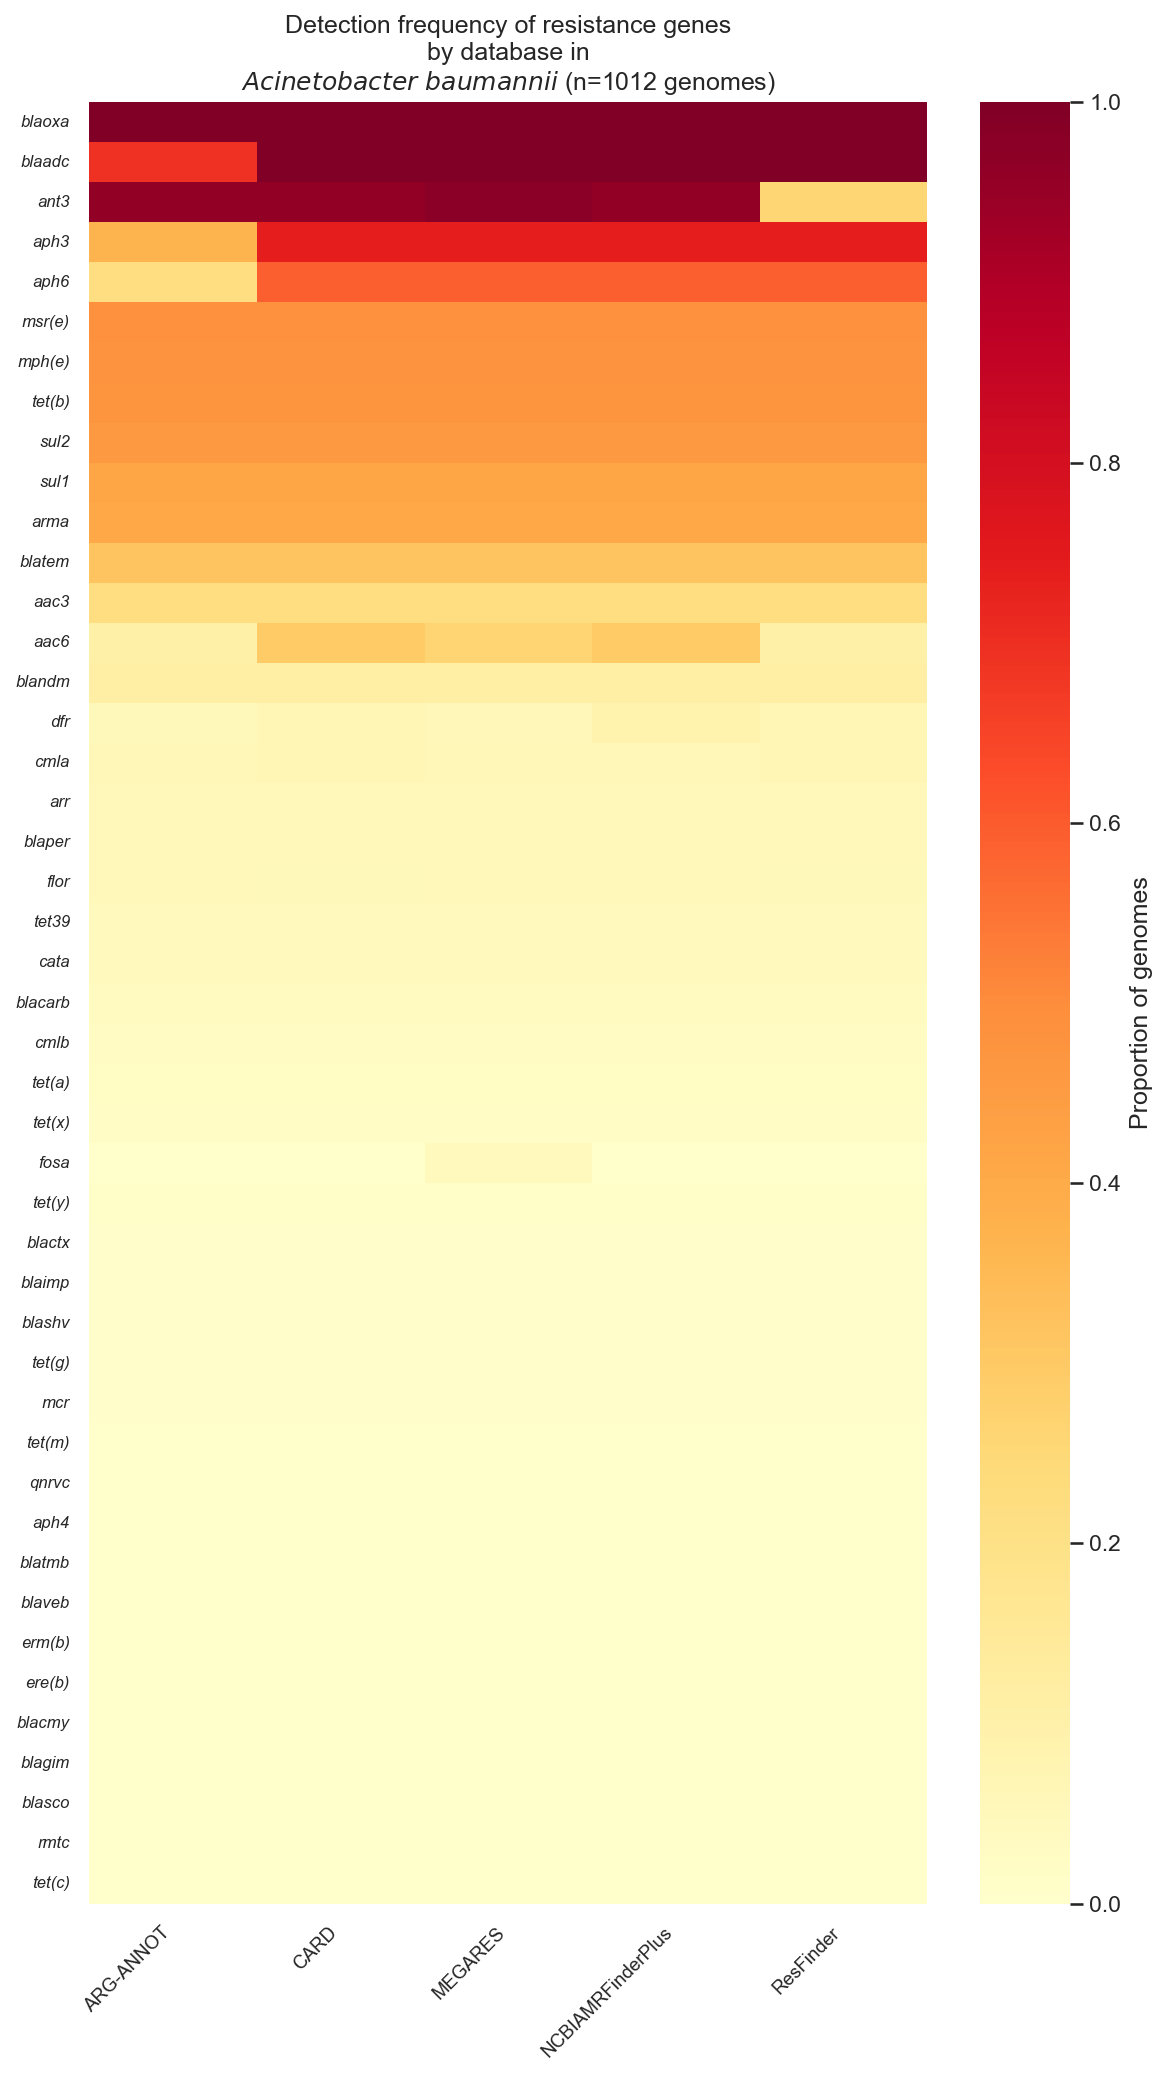

Figure saved to figures/05_freq_genes_per_db.png


In [33]:
# --- Frequency of each gene per database --------------------------------
fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(
    freq_db.T,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Proportion of genomes"},
    yticklabels=True,
    xticklabels=True,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Detection frequency of resistance genes\nby database in\n$\\it{Acinetobacter\\ baumannii}$ (n=1012 genomes)",
             fontsize=12)

# Gene names in italics on y-axis
labels_y = [label.get_text() for label in ax.get_yticklabels()]
ax.set_yticklabels(labels_y, fontproperties=italic_font, fontsize=8)

# Database names on x-axis
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("../../figures/05_freq_genes_por_db.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to figures/05_freq_genes_per_db.png")